# Manipulating the SFS
Parsing yields {class}`~sfsutils.spectrum.Spectrum` and {class}`~sfsutils.spectrum.Spectra` objects. A {class}`~sfsutils.spectrum.Spectrum` holds a single site-frequency spectrum; a {class}`~sfsutils.spectrum.Spectra` holds a named collection, one entry per type, such as the neutral and selected spectra produced by a stratified parse. Both expose the operations needed to inspect and reshape spectra, including indexing, grouping, folding, resampling, serialisation, and plotting. The examples below build spectra directly to illustrate these operations, but in practice they are usually returned by the {class}`~sfsutils.parser.Parser`.

In [1]:
setwd("~/PycharmProjects/SFSUtils/")
reticulate::use_condaenv("/Users/janek/miniforge3/envs/sfsutils-dev", required = TRUE)
dir.create("out", showWarnings = FALSE)


In [2]:
library(sfsutils)

su <- load_sfsutils()

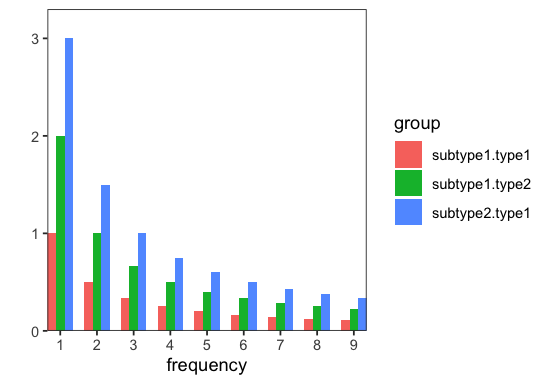

In [3]:
# create spectra with two subtypes and two types
spectra <- su$Spectra$from_spectra(list(
  "subtype1.type1" = su$Spectrum$standard_kingman(10) * 1,
  "subtype1.type2" = su$Spectrum$standard_kingman(10) * 2,
  "subtype2.type1" = su$Spectrum$standard_kingman(10) * 3
))

# plot spectra
p <- spectra$plot()

We access types by their index from which we obtain a {class}`~sfsutils.spectrum.Spectrum` object.

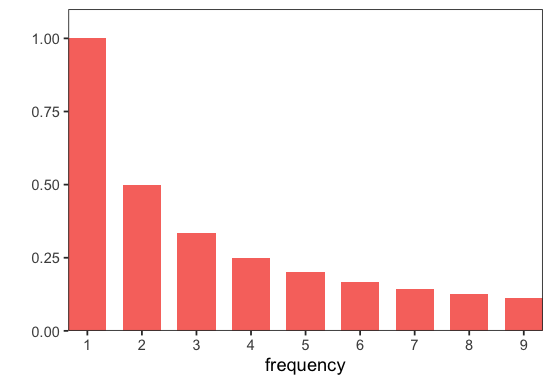

In [4]:
sfs <- spectra["subtype1.type1"]

p <- sfs$plot()

We can also use wildcards to access multiple types at once.

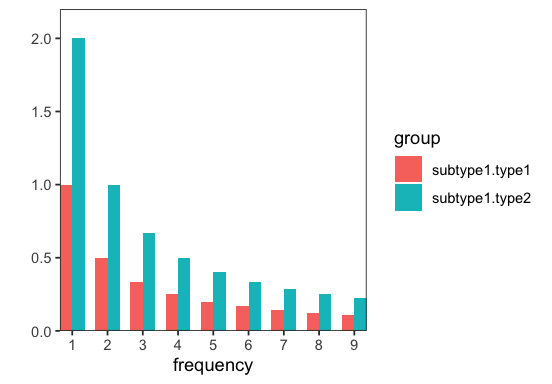

In [5]:
p <- spectra["subtype1.*"]$plot()

## Grouping
To get rid of the subtypes, we can merge the spectra over the specified number of groups.

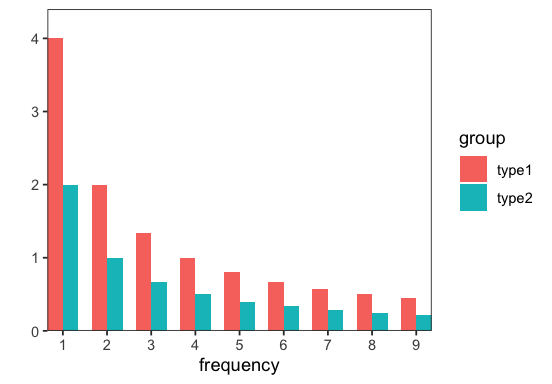

In [6]:
p <- spectra$merge_groups(1)$plot()

All subtypes for each type are merged into a single spectrum by adding them up.

## Serialization
We can also save the spectra to a file and restore them again.

In [7]:
spectra$to_file("out/spectra.csv")

spectra2 <- su$Spectra$from_file("out/spectra.csv")

## Prefixing
Here we prefix the spectra with a string to distinguish them and then combine them into a single spectra object.

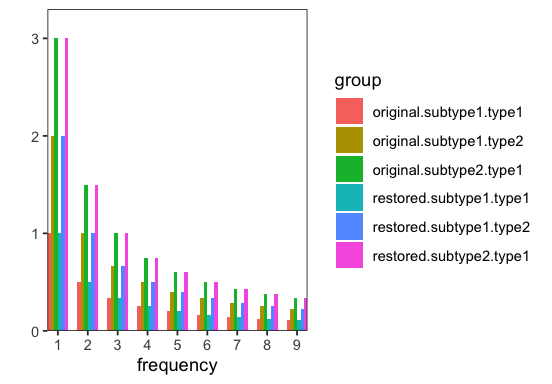

In [8]:
p <- spectra$prefix('original')$combine(spectra2$prefix('restored'))$plot()

For a complete reference of the available methods and properties, see {class}`~sfsutils.spectrum.Spectra` and {class}`~sfsutils.spectrum.Spectrum`.

## Folded spectra
{class}`~sfsutils.spectrum.Spectrum` and {class}`~sfsutils.spectrum.Spectra` objects can also be folded by collapsing the bins corresponding to the derived allele counts onto the bins corresponding to the ancestral allele counts. Folding discards information, which is particularly noticeable when beneficial mutations are present. However, folded spectra are easier to obtain, and are robust to misspecification of the ancestral state, which is often unknown. A spectrum reports whether it has been folded through its {meth}`~sfsutils.spectrum.Spectrum.is_folded` method.

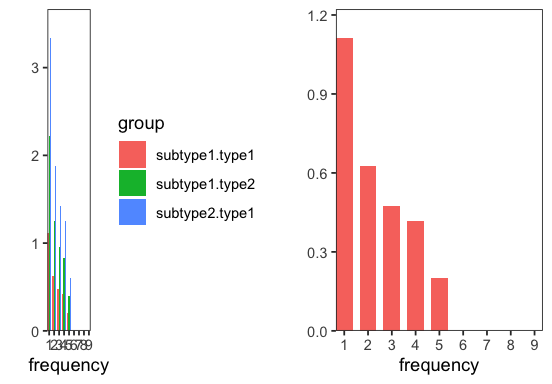

In [9]:
# create subplots by folding and combining the plots side by side

# fold spectra object
p1 <- spectra$fold()$plot(show = FALSE)

# fold spectrum object
p2 <- sfs$fold()$plot(show = FALSE)

cowplot::plot_grid(p1, p2, ncol = 2)